In [1]:
import hashlib
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = (
    "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/"
    "main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
)
with urllib.request.urlopen(DATA_URL) as response:
    dataset_bytes = response.read()

df_raw = pd.read_csv(io.BytesIO(dataset_bytes))
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"
df = df_raw[features + [target]].copy()

print("Dataset shape:", df.shape)
print("Dataset SHA-256:", hashlib.sha256(dataset_bytes).hexdigest())
print(df.head().to_string(index=False))


Dataset shape: (10000, 5)
Dataset SHA-256: 00a5cab178a8b7cd6e9157ee71dabc236ba7f20b1832336d358b07af14ba431f
 engine_displacement  horsepower  vehicle_weight  model_year  fuel_efficiency_mpg
                2180       243.0            3870        2006                 31.9
                2390       272.0            4210        2008                 31.3
                2320       267.0            4240        1996                 27.5
                2130       258.0            4490        1989                 28.5
                2580       304.0            4510        1994                 31.0


## EDA — Fuel-efficiency distribution

Inspect the target before fitting the regression model.


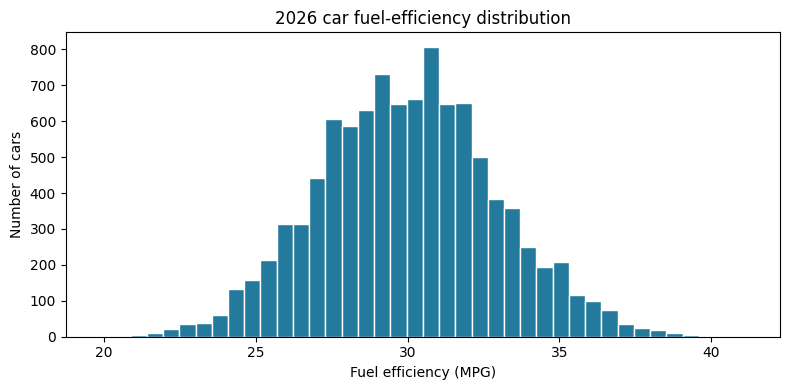

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Skewness: 0.0808


In [2]:
plt.figure(figsize=(8, 4))
plt.hist(df[target], bins=40, color="#247a9c", edgecolor="white")
plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Number of cars")
plt.title("2026 car fuel-efficiency distribution")
plt.tight_layout()
plt.show()

print(df[target].describe().to_string())
print(f"Skewness: {df[target].skew():.4f}")


The distribution is approximately symmetric, with **no pronounced long right tail**. Its mean is about 30 MPG and its skewness is about 0.081. Use the original MPG values as the target.


## Question 1 — Which feature has missing values?


In [3]:
missing_counts = df[features].isna().sum()
print(missing_counts.to_string())
missing_columns = missing_counts[missing_counts > 0].index.tolist()
assert len(missing_columns) == 1
q1_answer = missing_columns[0]
print("\nQ1 answer:", q1_answer)


engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0

Q1 answer: horsepower


**Answer: `horsepower`.** It has 877 missing values. The other three features have none.


## Question 2 — What is the median horsepower?


In [4]:
q2_answer = df["horsepower"].median()
print("Q2 answer:", q2_answer)


Q2 answer: 254.0


**Answer: 254.** Pandas computes this median from the observed values, ignoring missing entries.


## Prepare the split and regression functions

Use the assignment's shuffle procedure: 60% training, 20% validation, and 20% test. Questions 3–4 use seed 42.

The regression function adds an intercept column and solves the normal equation. Regularization adds `r` to the diagonal, including the intercept, as in the lesson implementation. Every missing value is filled with a value supplied by the caller.


In [5]:
def split_dataset(data, seed):
    n = len(data)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    train = data.iloc[idx[:n_train]].copy()
    val = data.iloc[idx[n_train:n_train + n_val]].copy()
    test = data.iloc[idx[n_train + n_val:]].copy()
    return train, val, test


def prepare_X(data, fill_value=0):
    return data[features].fillna(fill_value).to_numpy(dtype=float)


def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv @ X.T @ y
    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv @ X.T @ y
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


df_train, df_val, df_test = split_dataset(df, seed=42)
y_train = df_train[target].to_numpy()
y_val = df_val[target].to_numpy()

# Check that all rows belong to exactly one split.
assert set(df_train.index).isdisjoint(df_val.index)
assert set(df_train.index).isdisjoint(df_test.index)
assert set(df_val.index).isdisjoint(df_test.index)
assert len(df_train) + len(df_val) + len(df_test) == len(df)
print("Train / validation / test:", len(df_train), len(df_val), len(df_test))


Train / validation / test: 6000 2000 2000


## Question 3 — Zero or mean imputation?

Compare unregularized models on validation RMSE, rounded to three decimals. Calculate the imputation mean from training data only.


In [6]:
training_mean = df_train["horsepower"].mean()
q3_rows = []

for method, fill_value in [("With 0", 0), ("With mean", training_mean)]:
    X_train = prepare_X(df_train, fill_value)
    X_val = prepare_X(df_val, fill_value)
    w0, w = train_linear_regression(X_train, y_train)
    score = float(rmse(y_val, w0 + X_val @ w))
    q3_rows.append({"Method": method, "RMSE": score, "RMSE (3 decimals)": round(score, 3)})

q3_results = pd.DataFrame(q3_rows)
print("Training horsepower mean:", training_mean)
print(q3_results.to_string(index=False))
rounded_scores = q3_results["RMSE (3 decimals)"]
q3_answer = (
    "Both are equally good" if rounded_scores.nunique() == 1
    else q3_results.loc[rounded_scores.idxmin(), "Method"]
)
print("\nQ3 answer:", q3_answer)


Training horsepower mean: 254.46338337605272
   Method     RMSE  RMSE (3 decimals)
   With 0 2.205293              2.205
With mean 2.201817              2.202

Q3 answer: With mean


**Answer: With mean.** Validation RMSE is **2.202** with mean imputation and **2.205** with zero imputation. Lower RMSE means better predictions. Both splits use the same mean calculated from the training set.


## Question 4 — Which regularization strength is best?

Fill missing values with zero. Compare the specified `r` values using validation RMSE rounded to four decimals; select the smallest `r` if tied.


In [7]:
X_train_zero = prepare_X(df_train, fill_value=0)
X_val_zero = prepare_X(df_val, fill_value=0)
q4_rows = []

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)
    score = float(rmse(y_val, w0 + X_val_zero @ w))
    q4_rows.append({"r": r, "RMSE": score, "RMSE (4 decimals)": round(score, 4)})

q4_results = pd.DataFrame(q4_rows)
best_rounded_score = q4_results["RMSE (4 decimals)"].min()
q4_answer = q4_results.loc[
    q4_results["RMSE (4 decimals)"] == best_rounded_score, "r"
].min()
print(q4_results.to_string(index=False))
print(f"\nQ4 answer: r = {q4_answer:g}")


     r     RMSE  RMSE (4 decimals)
  0.00 2.205293             2.2053
  0.01 2.205828             2.2058
  0.10 2.224143             2.2241
  1.00 2.349229             2.3492
  5.00 2.409380             2.4094
 10.00 2.419470             2.4195
100.00 2.429202             2.4292

Q4 answer: r = 0


**Answer: `r = 0`.** Its validation RMSE is **2.2053**, the lowest among the tested settings. Regularization does not improve this model on this split.


## Question 5 — How much do scores vary across split seeds?

Repeat the split with seeds 0–9, fill missing values with zero, and fit unregularized regression. Compute `np.std` of the ten validation scores, then round to three decimals.


In [8]:
q5_rows = []

for seed in range(10):
    train_seed, val_seed, _ = split_dataset(df, seed=seed)
    X_train_seed = prepare_X(train_seed, fill_value=0)
    X_val_seed = prepare_X(val_seed, fill_value=0)
    y_train_seed = train_seed[target].to_numpy()
    y_val_seed = val_seed[target].to_numpy()

    w0, w = train_linear_regression(X_train_seed, y_train_seed)
    score = float(rmse(y_val_seed, w0 + X_val_seed @ w))
    q5_rows.append({"Seed": seed, "Validation RMSE": score})

q5_results = pd.DataFrame(q5_rows)
std = float(np.std(q5_results["Validation RMSE"].to_numpy()))
q5_answer = round(std, 3)
print(q5_results.to_string(index=False))
print("\nStandard deviation:", std)
print("Q5 answer:", q5_answer)


 Seed  Validation RMSE
    0         2.239204
    1         2.202113
    2         2.163420
    3         2.204359
    4         2.201880
    5         2.245785
    6         2.269721
    7         2.190795
    8         2.216611
    9         2.207037

Standard deviation: 0.028781274078191175
Q5 answer: 0.029


**Answer: 0.029.** The unrounded standard deviation is about 0.028781. This is small relative to an RMSE of about 2.2 MPG, so the scores vary little across these splits. `np.std` uses `ddof=0` by default.


## Question 6 — What is the final test RMSE?

Use seed 9, combine training and validation data, fill missing values with zero, and fit with `r = 0.001`. Evaluate once on the held-out test set.


In [9]:
train_9, val_9, test_9 = split_dataset(df, seed=9)
full_train_9 = pd.concat([train_9, val_9], ignore_index=True)

X_full_train_9 = prepare_X(full_train_9, fill_value=0)
y_full_train_9 = full_train_9[target].to_numpy()
X_test_9 = prepare_X(test_9, fill_value=0)
y_test_9 = test_9[target].to_numpy()

w0_final, w_final = train_linear_regression_reg(
    X_full_train_9, y_full_train_9, r=0.001
)
test_predictions = w0_final + X_test_9 @ w_final
q6_rmse = float(rmse(y_test_9, test_predictions))
q6_answer = round(q6_rmse, 3)

print("Combined training rows:", len(full_train_9))
print("Test rows:", len(test_9))
print("Test RMSE:", q6_rmse)
print("Q6 answer:", q6_answer)


Combined training rows: 8000
Test rows: 2000
Test RMSE: 2.235827747191731
Q6 answer: 2.236


**Answer: 2.236.** The calculated test RMSE is approximately **2.235828 MPG**, which rounds to the listed option.


In [10]:
answers = pd.DataFrame({
    "Question": ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6"],
    "Answer": [q1_answer, f"{q2_answer:g}", q3_answer, f"{q4_answer:g}",
               f"{q5_answer:.3f}", f"{q6_answer:.3f}"]
})
print(answers.to_string(index=False))


Question     Answer
      Q1 horsepower
      Q2        254
      Q3  With mean
      Q4          0
      Q5      0.029
      Q6      2.236
